In [7]:

# ============================================================
# Notebook: Credit Risk Modeling (Leakage-Safe) + LogReg
# ============================================================
# Goal:
# 1) Build leakage-safe features anchored to evaluation_date
# 2) Train Logistic Regression model and report strong metrics
# 3) Include feature selection option (L1 / Elastic Net)
# ============================================================

import os
import sys
import importlib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

# -------------------------
# 1) Load raw data
# -------------------------
consumers = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
accounts  = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
transactions = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")

cat_map = (
    pd.read_csv("/uss/hdsi-prismdata/q2-ucsd-cat-map.csv")
      .rename(columns={"category_id": "category", "category": "category_name"})
)

consumers["evaluation_date"] = pd.to_datetime(consumers["evaluation_date"])

print("consumers:", consumers.shape)
print("accounts:", accounts.shape)
print("transactions:", transactions.shape)

# -------------------------
# 2) Import your backfill builder (repo-local scripts/)
# -------------------------
# Make sure your notebook is located one folder below the repo root that contains scripts/
repo_root = os.path.abspath("..")
sys.path.insert(0, repo_root)

# kick out any already-loaded wrong 'scripts' (from site-packages), if present
sys.modules.pop("scripts", None)
sys.modules.pop("scripts.backfill_transactions", None)
importlib.invalidate_caches()

from scripts.backfill_transactions import build_backfill_df

# -------------------------
# 3) Build backfilled transaction rows + daily EOD series
# -------------------------
rows_df = build_backfill_df()
rows_df["date"] = pd.to_datetime(rows_df["date"])
rows_df = rows_df.sort_values(["prism_consumer_id", "date"])
rows_df["day"] = rows_df["date"].dt.normalize()

rows_daily = (
    rows_df.groupby(["prism_consumer_id", "day"], as_index=False)
          .agg(
              balance=("balance", "last"),
              amount_change=("amount_change", "sum"),  # NOTE: could be unsigned; we keep it for net changes
              n_tx=("amount_change", "size"),
              DQ_TARGET=("DQ_TARGET", "max")
          )
          .rename(columns={"day": "date"})
)

# attach evaluation_date and force leakage-safe cutoff
rows_daily = rows_daily.merge(
    consumers[["prism_consumer_id", "evaluation_date", "DQ_TARGET"]],
    on="prism_consumer_id",
    how="inner",
    suffixes=("", "_cons")
)
rows_daily["DQ_TARGET"] = rows_daily["DQ_TARGET_cons"]
rows_daily = rows_daily.drop(columns=["DQ_TARGET_cons"])
rows_daily = rows_daily[rows_daily["date"] <= rows_daily["evaluation_date"]].copy()

print("rows_df:", rows_df.shape, "rows_daily:", rows_daily.shape)

# -------------------------
# 4) Signed transaction change (fixes exploding credit/debit ratios)
# -------------------------
tx = rows_df.copy()
tx["date"] = pd.to_datetime(tx["date"])

tx["signed_change"] = np.where(
    tx["credit_or_debit"].astype(str).str.upper().eq("CREDIT"),
    tx["amount_change"].astype(float),
    -tx["amount_change"].astype(float),
)

# -------------------------
# 5) Leakage-safe daily window features (anchored to evaluation_date)
# -------------------------
def window_daily_features_asof(rows_daily_df: pd.DataFrame, days: int) -> pd.DataFrame:
    d = rows_daily_df.copy()
    cutoff = d["evaluation_date"] - pd.Timedelta(days=days)
    d = d[d["date"] >= cutoff]

    out = d.groupby("prism_consumer_id").agg(
        **{
            f"balance__mean__{days}d": ("balance", "mean"),
            f"balance__min__{days}d": ("balance", "min"),
            f"balance__std__{days}d": ("balance", "std"),
            f"balance__pct_negative__{days}d": ("balance", lambda x: (x < 0).mean()),
            f"cashflow__net__{days}d": ("amount_change", "sum"),
            f"cashflow__mean_daily__{days}d": ("amount_change", "mean"),
            f"cashflow__volatility__{days}d": ("amount_change", "std"),
            f"n_tx__{days}d": ("n_tx", "sum"),
            f"n_days__{days}d": ("date", "nunique"),
        }
    )
    return out

# all-time (already capped at evaluation_date)
bal_all = rows_daily.groupby("prism_consumer_id").agg(
    balance__mean__all=("balance", "mean"),
    balance__median__all=("balance", "median"),
    balance__min__all=("balance", "min"),
    balance__max__all=("balance", "max"),
    balance__std__all=("balance", "std"),
    balance__pct_negative__all=("balance", lambda x: (x < 0).mean()),
    balance__pct_below_100__all=("balance", lambda x: (x < 100).mean()),
    balance__pct_below_500__all=("balance", lambda x: (x < 500).mean()),
    n_days__all=("date", "nunique"),
)

daily_30  = window_daily_features_asof(rows_daily, 30)
daily_60  = window_daily_features_asof(rows_daily, 60)
daily_90  = window_daily_features_asof(rows_daily, 90)
daily_180 = window_daily_features_asof(rows_daily, 180)

# -------------------------
# 6) Transaction activity features (signed)
# -------------------------
tx_all = tx.groupby("prism_consumer_id").agg(
    tx__n__all=("signed_change", "size"),
    tx__std_amount__all=("signed_change", "std"),
    credit__total__all=("signed_change", lambda x: x[x > 0].sum()),
    debit__total__all=("signed_change", lambda x: np.abs(x[x < 0]).sum()),
    tx__max_credit__all=("signed_change", lambda x: x[x > 0].max() if (x > 0).any() else 0.0),
    tx__max_debit__all=("signed_change", lambda x: np.abs(x[x < 0]).max() if (x < 0).any() else 0.0),
)
tx_all["credit_debit__ratio__all"] = tx_all["credit__total__all"] / (tx_all["debit__total__all"] + 1.0)

# -------------------------
# 7) Category features + group burden features
# -------------------------
txc = transactions.merge(cat_map, on="category", how="left").copy()
txc["posted_date"] = pd.to_datetime(txc["posted_date"])

txc["signed_amount"] = np.where(
    txc["credit_or_debit"].astype(str).str.upper().eq("CREDIT"),
    txc["amount"].astype("float64"),
    -txc["amount"].astype("float64"),
)

TOPK = 30
top_cats = txc["category"].value_counts().head(TOPK).index
txc = txc[txc["category"].isin(top_cats)].copy()

# all-time cats
cat_all = (
    txc.groupby(["prism_consumer_id", "category"])
       .agg(cat_net_total=("signed_amount", "sum"),
            cat_n=("signed_amount", "count"))
       .unstack(fill_value=0)
)
cat_all.columns = [f"cat_{int(c)}__{stat}__all" for stat, c in cat_all.columns]

# 90d cats anchored to evaluation_date (leakage-safe)
eval_dates = consumers.set_index("prism_consumer_id")["evaluation_date"]
tmp = txc.join(eval_dates.rename("evaluation_date"), on="prism_consumer_id", how="inner")
tmp = tmp[tmp["posted_date"] <= tmp["evaluation_date"]]
tmp = tmp[tmp["posted_date"] >= (tmp["evaluation_date"] - pd.Timedelta(days=90))]

cat_90 = (
    tmp.groupby(["prism_consumer_id", "category"])
       .agg(cat_net_total=("signed_amount", "sum"),
            cat_n=("signed_amount", "count"))
       .unstack(fill_value=0)
)
cat_90.columns = [f"cat_{int(c)}__{stat}__90d" for stat, c in cat_90.columns]

INCOME_CATS = {2,3,6,7,8,9,42,45,49}
ESSENTIAL_CATS = {11,12,13,17,18,22,23,26,27,29,31,32,33,34,36,38}
DISCRETIONARY_CATS = {14,16,19,20,21,24,28,30,35,39,40,46,48}

income_total = (
    txc[txc["category"].isin(INCOME_CATS)]
    .groupby("prism_consumer_id")["signed_amount"]
    .apply(lambda x: x[x > 0].sum())
    .rename("income__total__all")
)

ess_total = (
    txc[txc["category"].isin(ESSENTIAL_CATS)]
    .groupby("prism_consumer_id")["signed_amount"]
    .apply(lambda x: np.abs(x[x < 0]).sum())
    .rename("essentials_spend__total__all")
)

disc_total = (
    txc[txc["category"].isin(DISCRETIONARY_CATS)]
    .groupby("prism_consumer_id")["signed_amount"]
    .apply(lambda x: np.abs(x[x < 0]).sum())
    .rename("discretionary_spend__total__all")
)

group_feats = pd.concat([income_total, ess_total, disc_total], axis=1).fillna(0)
group_feats["essentials__pct_of_income__all"] = group_feats["essentials_spend__total__all"] / (group_feats["income__total__all"] + 1.0)
group_feats["discretionary__pct_of_income__all"] = group_feats["discretionary_spend__total__all"] / (group_feats["income__total__all"] + 1.0)

consumers: (15000, 4)
accounts: (24466, 5)
transactions: (6407321, 6)
rows_df: (5213287, 7) rows_daily: (1094385, 7)


In [9]:


# -------------------------
# 8) Assemble final features + label  (FIXED)
# -------------------------

# Build y safely (keep only labeled consumers)
y = consumers.set_index("prism_consumer_id")["DQ_TARGET"]
y = pd.to_numeric(y, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().astype(int)

# Assemble X (features)
X = (
    bal_all
    .join([daily_30, daily_60, daily_90, daily_180], how="left")
    .join(tx_all, how="left")
    .join(cat_all, how="left")
    .join(cat_90, how="left")
    .join(group_feats, how="left")
)

# Join X with y (this automatically drops unlabeled consumers)
features_df = (
    X.join(y.rename("DQ_TARGET"), how="inner")
     .replace([np.inf, -np.inf], np.nan)
     .fillna(0)
)

X = features_df.drop(columns=["DQ_TARGET"]).copy()
y = features_df["DQ_TARGET"].astype(int).copy()

print("Final X:", X.shape, "positive rate:", y.mean())
print("Consumers kept:", len(y), "Dropped (unlabeled or missing feats):", consumers.shape[0] - len(y))


# -------------------------
# 9) 3-way split: train/val/test (60/20/20)
# -------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print("Sizes:", len(X_train), len(X_val), len(X_test))

Final X: (9779, 177) positive rate: 0.09142039063298905
Consumers kept: 9779 Dropped (unlabeled or missing feats): 5221
Sizes: 5867 1956 1956


In [12]:


# -------------------------
# 10) Metrics helpers (ROC-AUC, PR-AUC, KS, confusion matrix)
# -------------------------
def ks_stat(y_true, y_prob):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def report_split(name, Xs, ys, model, threshold=0.50):
    prob = model.predict_proba(Xs)[:, 1]
    pred = (prob >= threshold).astype(int)

    out = {
        "split": name,
        "roc_auc": roc_auc_score(ys, prob),
        "pr_auc": average_precision_score(ys, prob),
        "ks": ks_stat(ys, prob),
        "accuracy": accuracy_score(ys, pred),
        "precision": precision_score(ys, pred, zero_division=0),
        "recall": recall_score(ys, pred, zero_division=0),
        "f1": f1_score(ys, pred, zero_division=0),
    }
    print(pd.Series(out))
    print("Confusion matrix:\n", confusion_matrix(ys, pred))
    return out

# -------------------------
# 11) Baseline Logistic Regression (L2)
# -------------------------
logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        solver="liblinear",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logreg.fit(X_train, y_train)

# choose threshold on validation (maximize F1)
val_prob = logreg.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)

best_t, best_f1 = 0.50, -1
for t in thresholds:
    f1 = f1_score(y_val, (val_prob >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold (val F1):", best_t, "F1:", best_f1)

report_split("train", X_train, y_train, logreg, threshold=best_t)
report_split("val",   X_val,   y_val,   logreg, threshold=best_t)
report_split("test",  X_test,  y_test,  logreg, threshold=best_t)

# -------------------------
# 12) Feature selection option: L1 Logistic Regression
# -------------------------
l1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        solver="saga",
        penalty="l1",
        C=0.2,                 # tune this if needed (smaller => fewer features)
        class_weight="balanced",
        max_iter=6000,
        random_state=42
    ))
])

l1.fit(X_train, y_train)
coef = l1.named_steps["model"].coef_.ravel()
selected = np.array(X.columns)[coef != 0]
print("L1 selected:", len(selected))
print("Top selected features:", selected[:25])


# evaluate L1 model using selected columns for reporting
report_split("val (L1)",  X_val,  y_val,  l1, threshold=best_t)
report_split("test (L1)", X_test, y_test, l1, threshold=best_t)


# -------------------------
# 13) Homework short answers (printable)
# -------------------------
print("\nHOMEWORK ANSWERS:")
print("\nQ: How many splits and purpose?")
print("- Train / Validation / Test (3 splits).")
print("- Train fits parameters; Validation tunes hyperparameters/threshold; Test is final unbiased score.")

print("\nQ1: More sophisticated features with more time?")
print("- Paycheck periodicity & stability (biweekly/monthly deposit detection)")
print("- Cash buffer: balance / avg daily debit (days-of-cash)")
print("- Overdraft episodes: count, duration, recovery time")
print("- Balance max drawdown + drawdown duration")
print("- Spending-mix drift: last 30d vs prior 90d category shares")
print("- Downside volatility: std of negative daily changes only")

print("\nQ2: Method to reduce features?")
print("- L1 / Elastic Net Logistic Regression (regularization) to shrink weak features to 0 (interpretable + reduces overfit).")


Best threshold (val F1): 0.65 F1: 0.32646048109965636
split           train
roc_auc      0.821557
pr_auc       0.268095
ks           0.506452
accuracy      0.81592
precision    0.268707
recall       0.589552
f1           0.369159
dtype: object
Confusion matrix:
 [[4471  860]
 [ 220  316]]
split             val
roc_auc      0.753308
pr_auc       0.219554
ks           0.409186
accuracy     0.799591
precision    0.235732
recall       0.530726
f1            0.32646
dtype: object
Confusion matrix:
 [[1469  308]
 [  84   95]]
split            test
roc_auc      0.766743
pr_auc       0.216535
ks           0.451351
accuracy     0.790389
precision    0.221687
recall       0.513966
f1           0.309764
dtype: object
Confusion matrix:
 [[1454  323]
 [  87   92]]
L1 selected: 130
Top selected features: ['balance__min__all' 'balance__max__all' 'balance__pct_negative__all'
 'balance__pct_below_100__all' 'balance__pct_below_500__all' 'n_days__all'
 'balance__mean__30d' 'balance__min__30d' 'balance__s

In [ ]:
#Final Test-Set Performance + Visuals

In [13]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve

# -------------------------
# 1) Get test-set predictions
# -------------------------
y_test_prob = logreg.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_t).astype(int)

# -------------------------
# 2) Summary performance table (TEST)
# -------------------------
summary_stats = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "KS",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Positive rate"
    ],
    "Value": [
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob),
        ks_stat(y_test, y_test_prob),
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        y_test.mean()
    ]
})

summary_stats


,Metric,Value
0,ROC-AUC,0.766743
1,PR-AUC,0.216535
2,KS,0.451351
3,Accuracy,0.790389
4,Precision,0.221687
5,Recall,0.513966
6,F1-score,0.309764
7,Positive rate,0.091513


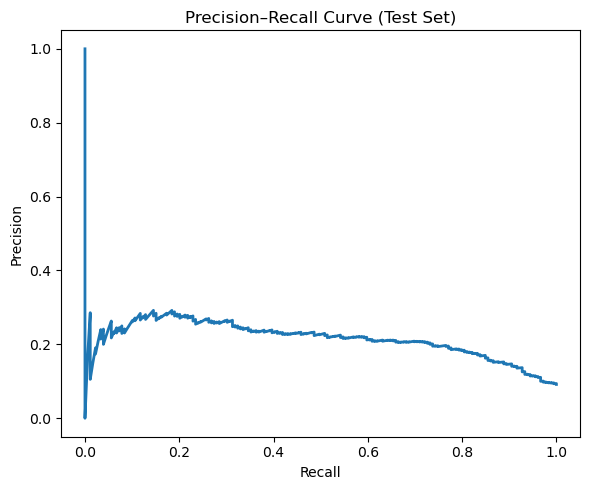

In [14]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.tight_layout()
plt.show()


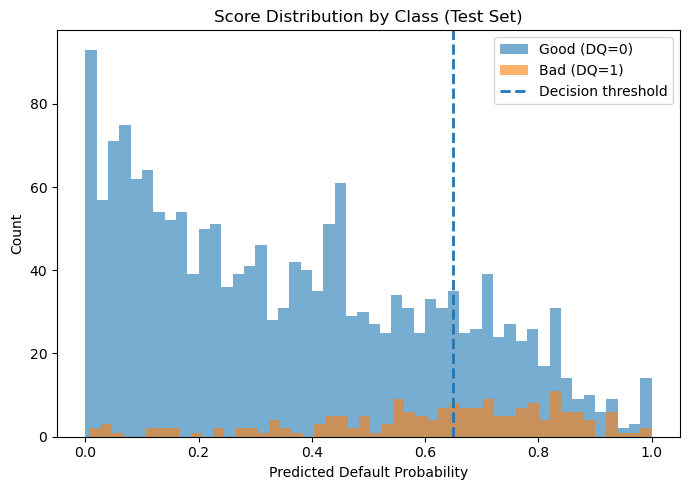

In [15]:
plt.figure(figsize=(7, 5))

plt.hist(
    y_test_prob[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Good (DQ=0)"
)

plt.hist(
    y_test_prob[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Bad (DQ=1)"
)

plt.axvline(best_t, linestyle="--", linewidth=2, label="Decision threshold")

plt.xlabel("Predicted Default Probability")
plt.ylabel("Count")
plt.title("Score Distribution by Class (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# extract coefficients
coef = logreg.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(20)

top_coef


,feature,coefficient,abs_coef
44,n_days__180d,-2.859158,2.859158
46,tx__std_amount__all,-2.687665,2.687665
43,n_tx__180d,2.118140,2.118140
0,balance__mean__all,-2.107096,2.107096
42,cashflow__volatility__180d,2.094347,2.094347
27,balance__mean__90d,2.015414,2.015414
9,balance__mean__30d,-2.008018,2.008018
33,cashflow__volatility__90d,-1.812590,1.812590
2,balance__min__all,1.657449,1.657449
1,balance__median__all,1.473238,1.473238


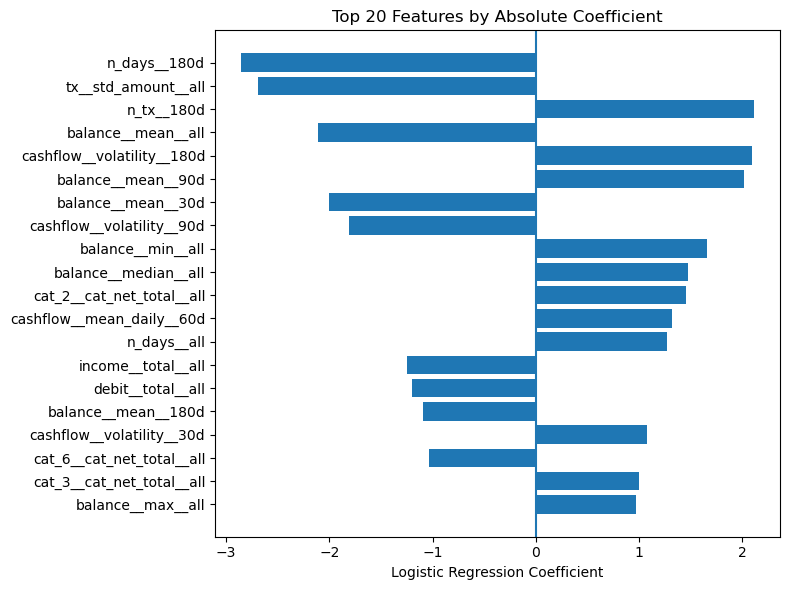

In [17]:
plt.figure(figsize=(8, 6))
plt.barh(
    top_coef["feature"],
    top_coef["coefficient"]
)
plt.axvline(0)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top 20 Features by Absolute Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


,metric,value
0,ROC-AUC,0.766743
1,PR-AUC,0.216535
2,KS,0.451351
3,Accuracy,0.790389
4,Precision,0.221687
5,Recall,0.513966
6,F1,0.309764
7,Positive rate,0.091513


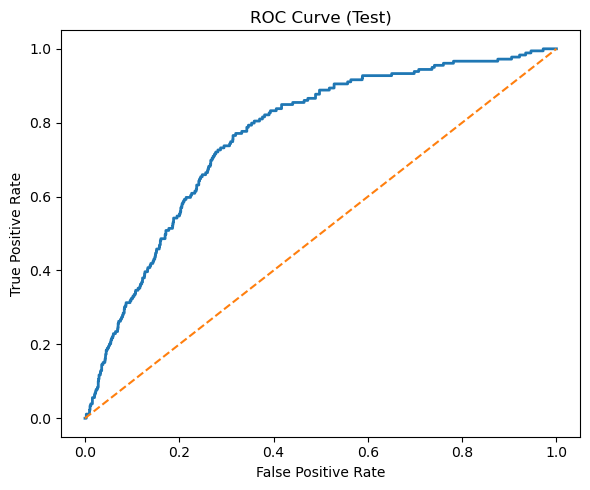

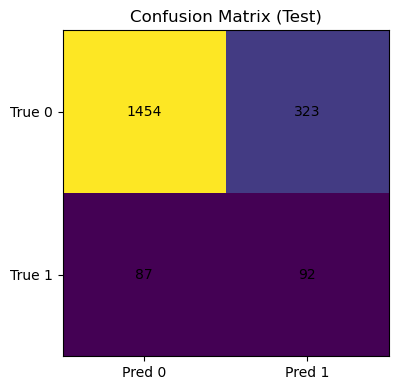

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve

# ---- predictions ----
y_test_prob = logreg.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_t).astype(int)

# ---- stats table ----
stats = pd.DataFrame({
    "metric": ["ROC-AUC","PR-AUC","KS","Accuracy","Precision","Recall","F1","Positive rate"],
    "value": [
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob),
        ks_stat(y_test, y_test_prob),
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        y_test.mean()
    ]
})
display(stats)

# ---- ROC ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.tight_layout()
plt.show()



# ---- confusion matrix plot ----
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4.5,4))
plt.imshow(cm)
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()



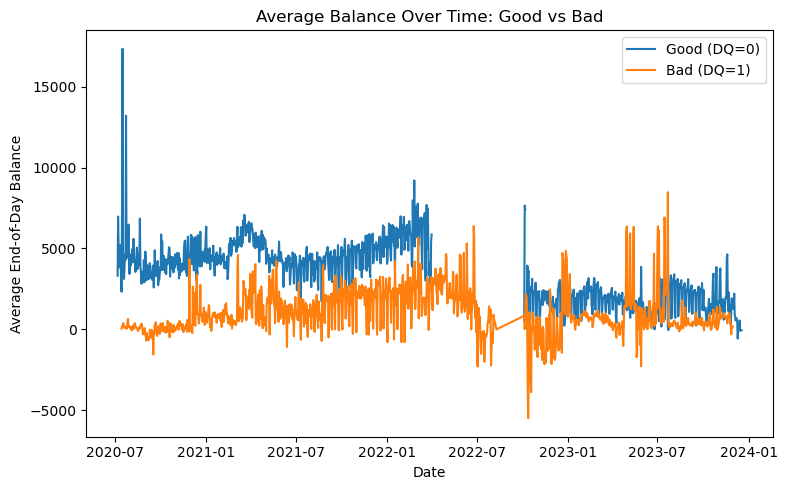

In [26]:
tmp = rows_daily.dropna(subset=["DQ_TARGET"]).copy()
tmp["date"] = pd.to_datetime(tmp["date"])

avg_by_day = tmp.groupby(["date", "DQ_TARGET"])["balance"].mean().reset_index()
pivot = avg_by_day.pivot(index="date", columns="DQ_TARGET", values="balance").sort_index()

plt.figure(figsize=(8,5))
plt.plot(pivot.index, pivot.get(0), label="Good (DQ=0)")
plt.plot(pivot.index, pivot.get(1), label="Bad (DQ=1)")
plt.xlabel("Date")
plt.ylabel("Average End-of-Day Balance")
plt.title("Average Balance Over Time: Good vs Bad")
plt.legend()
plt.tight_layout()
plt.show()


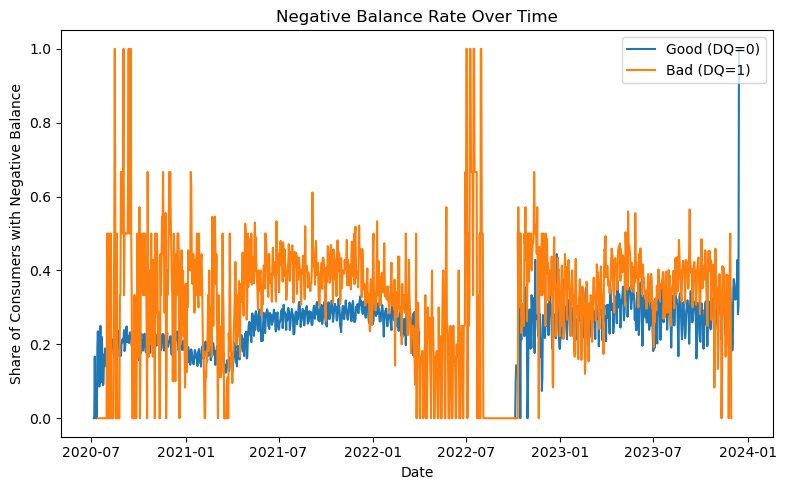

In [27]:
neg_rate = (
    tmp.assign(neg=lambda d: (d["balance"] < 0).astype(int))
       .groupby(["date", "DQ_TARGET"])["neg"]
       .mean()
       .reset_index()
)
pivot = neg_rate.pivot(index="date", columns="DQ_TARGET", values="neg").sort_index()

plt.figure(figsize=(8,5))
plt.plot(pivot.index, pivot.get(0), label="Good (DQ=0)")
plt.plot(pivot.index, pivot.get(1), label="Bad (DQ=1)")
plt.xlabel("Date")
plt.ylabel("Share of Consumers with Negative Balance")
plt.title("Negative Balance Rate Over Time")
plt.legend()
plt.tight_layout()
plt.show()


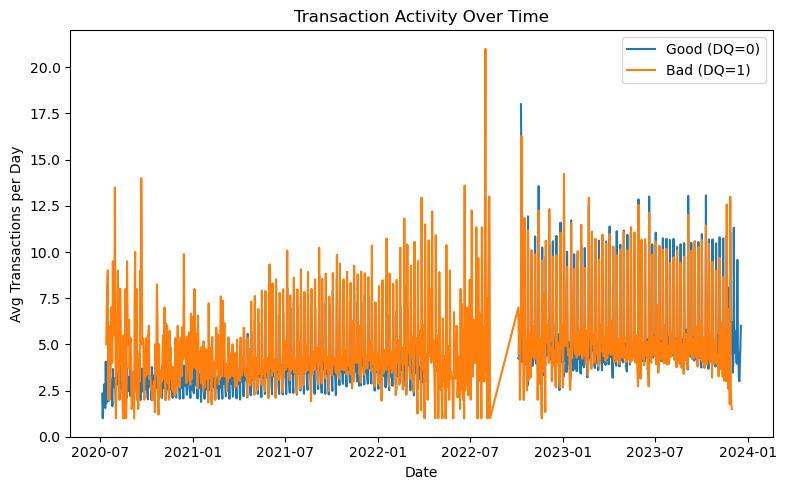

In [28]:
tx_rate = tmp.groupby(["date", "DQ_TARGET"])["n_tx"].mean().reset_index()
pivot = tx_rate.pivot(index="date", columns="DQ_TARGET", values="n_tx").sort_index()

plt.figure(figsize=(8,5))
plt.plot(pivot.index, pivot.get(0), label="Good (DQ=0)")
plt.plot(pivot.index, pivot.get(1), label="Bad (DQ=1)")
plt.xlabel("Date")
plt.ylabel("Avg Transactions per Day")
plt.title("Transaction Activity Over Time")
plt.legend()
plt.tight_layout()
plt.show()


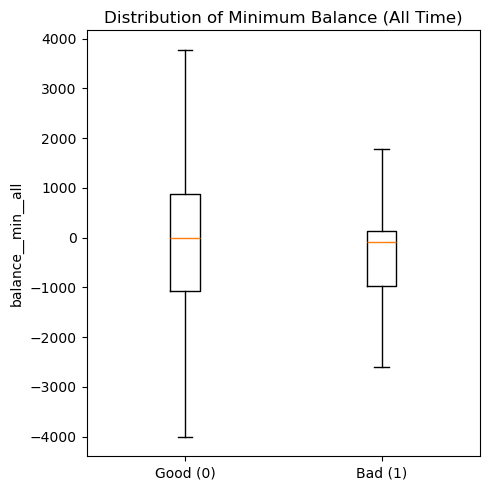

In [29]:
f = "balance__min__all"
good = features_df.loc[features_df["DQ_TARGET"]==0, f].dropna()
bad  = features_df.loc[features_df["DQ_TARGET"]==1, f].dropna()

plt.figure(figsize=(5,5))
plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"], showfliers=False)
plt.ylabel(f)
plt.title("Distribution of Minimum Balance (All Time)")
plt.tight_layout()
plt.show()


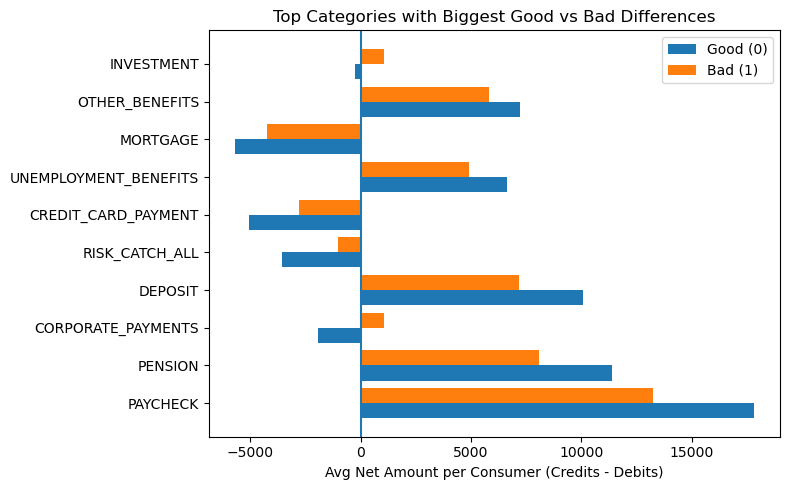

In [32]:
txc = transactions.merge(cat_map, on="category", how="left").copy()
txc["signed_amount"] = np.where(
    txc["credit_or_debit"].astype(str).str.upper().eq("CREDIT"),
    txc["amount"].astype(float),
    -txc["amount"].astype(float),
)

# attach consumer label
labels = consumers[["prism_consumer_id","DQ_TARGET"]].copy()
txc = txc.merge(labels, on="prism_consumer_id", how="inner")
txc = txc.dropna(subset=["DQ_TARGET"])
txc["DQ_TARGET"] = txc["DQ_TARGET"].astype(int)

# compute mean net per consumer-category, then average across consumers
per_cons_cat = (
    txc.groupby(["prism_consumer_id","DQ_TARGET","category_name"])["signed_amount"]
       .sum()
       .reset_index()
)

cat_summary = (
    per_cons_cat.groupby(["DQ_TARGET","category_name"])["signed_amount"]
               .mean()
               .reset_index()
)

# pick top 10 by absolute difference
pivot = cat_summary.pivot(index="category_name", columns="DQ_TARGET", values="signed_amount").fillna(0)
pivot["diff"] = (pivot.get(1,0) - pivot.get(0,0)).abs()
top10 = pivot.sort_values("diff", ascending=False).head(10).drop(columns=["diff"])

plt.figure(figsize=(8,5))
ypos = np.arange(len(top10.index))
plt.barh(ypos-0.2, top10.get(0,0).values, height=0.4, label="Good (0)")
plt.barh(ypos+0.2, top10.get(1,0).values, height=0.4, label="Bad (1)")
plt.yticks(ypos, top10.index)
plt.axvline(0)
plt.xlabel("Avg Net Amount per Consumer (Credits - Debits)")
plt.title("Top Categories with Biggest Good vs Bad Differences")
plt.legend()
plt.tight_layout()
plt.show()
